<a href="https://colab.research.google.com/github/gruuuuuuuu/yolo-practice/blob/main/yolo_v7_v8_26_2026_09_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U ultralytics roboflow scikit-learn opencv-python-headless pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 160.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 151.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 160.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 151.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requ

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("請先到 Runtime > Change runtime type > GPU")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

print("Roboflow API Key loaded.")

Roboflow API Key loaded.


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = (
    rf.workspace("s-workspace-cojhy")
      .project("pothole-detection-yolo-8j0qo")
)

version = project.version(12)

dataset = version.download("yolov8")

DATASET_ROOT = dataset.location

print("Dataset root:", DATASET_ROOT)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pothole-detection-yolo-12 in yolov8:: 100%|██████████| 10831/10831 [00:01<00:00, 8732.92it/s] 


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Dataset root: /content/pothole-detection-yolo-12


# **Cell 5｜查看 Dataset 結構**

In [ ]:
import os

for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

pothole-detection-yolo-12/
    test/
        labels/
        images/
    train/
        labels/
        images/
    valid/
        labels/
        images/


# **Cell 6｜把原本 Train / Valid / Test 合併回完整 Dataset Pool**

In [ ]:
from pathlib import Path
import pandas as pd

ROOT = Path(DATASET_ROOT)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for split in ["train", "valid", "test"]:
    image_dir = ROOT / split / "images"
    label_dir = ROOT / split / "labels"

    if not image_dir.exists():
        continue

    for img_path in image_dir.iterdir():

        if img_path.suffix.lower() not in image_extensions:
            continue

        label_path = label_dir / f"{img_path.stem}.txt"

        # 計算此圖片中 pothole bounding boxes 數量
        if label_path.exists():
            text = label_path.read_text().strip()

            if text:
                n_boxes = len(text.splitlines())
            else:
                n_boxes = 0
        else:
            n_boxes = 0

        records.append({
            "image": str(img_path),
            "label": str(label_path),
            "original_split": split,
            "n_boxes": n_boxes,
            "positive": int(n_boxes > 0)
        })

df = pd.DataFrame(records)

print("Total images :", len(df))
print("Positive     :", df["positive"].sum())
print("Negative     :", (df["positive"] == 0).sum())
print("Total boxes  :", df["n_boxes"].sum())

display(df.head())

Total images : 5413
Positive     : 2247
Negative     : 3166
Total boxes  : 5876


,image,label,original_split,n_boxes,positive
0,/content/pothole-detection-yolo-12/train/image...,/content/pothole-detection-yolo-12/train/label...,train,1,1
1,/content/pothole-detection-yolo-12/train/image...,/content/pothole-detection-yolo-12/train/label...,train,0,0
2,/content/pothole-detection-yolo-12/train/image...,/content/pothole-detection-yolo-12/train/label...,train,0,0
3,/content/pothole-detection-yolo-12/train/image...,/content/pothole-detection-yolo-12/train/label...,train,5,1
4,/content/pothole-detection-yolo-12/train/image...,/content/pothole-detection-yolo-12/train/label...,train,0,0


# **Cell 7｜檢查 class distribution**

In [ ]:
print("\nBox count distribution:")
print(df["n_boxes"].value_counts().sort_index())

print("\nPositive / Negative:")
print(df["positive"].value_counts())


Box count distribution:
n_boxes
0     3166
1      993
2      456
3      301
4      171
5       92
6       74
7       49
8       30
9       31
10      16
11      14
12       1
13       4
14       2
15       4
16       6
18       1
19       2
Name: count, dtype: int64

Positive / Negative:
positive
0    3166
1    2247
Name: count, dtype: int64


# **Cell 8｜建立 Stratification Label**

In [ ]:
def make_strata(n):
    if n == 0:
        return "0"
    elif n == 1:
        return "1"
    elif n == 2:
        return "2"
    else:
        return "3+"

df["strata"] = df["n_boxes"].apply(make_strata)

print(df["strata"].value_counts())

strata
0     3166
1      993
3+     798
2      456
Name: count, dtype: int64


In [ ]:
counts = df["strata"].value_counts()

rare = counts[counts < 5].index

if len(rare) > 0:
    print("少於 5 張的 strata:", list(rare))
    print("改使用 Positive / Negative stratification")
    df["strata"] = df["positive"].astype(str)

print("\nFinal strata:")
print(df["strata"].value_counts())


Final strata:
strata
0     3166
1      993
3+     798
2      456
Name: count, dtype: int64


# **Cell 9｜建立固定 5-Fold**

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

SEED = 42

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

df["fold"] = -1

for fold, (_, val_idx) in enumerate(
    skf.split(df, df["strata"]),
    start=1
):
    df.loc[val_idx, "fold"] = fold

print(df["fold"].value_counts().sort_index())

fold
1    1083
2    1083
3    1083
4    1082
5    1082
Name: count, dtype: int64


In [ ]:
fold_stats = df.groupby("fold").agg(
    images=("image", "count"),
    positive_images=("positive", "sum"),
    total_boxes=("n_boxes", "sum")
)

fold_stats["negative_images"] = (
    fold_stats["images"] - fold_stats["positive_images"]
)

display(fold_stats)

,images,positive_images,total_boxes,negative_images
fold,,,,
1,1083,450,1185,633
2,1083,450,1204,633
3,1083,450,1141,633
4,1082,448,1174,634
5,1082,449,1172,633


# **Cell 10｜儲存 5-Fold 分割資訊**

In [ ]:
df.to_csv("/content/pothole_5fold_split.csv", index=False)

print("Saved:")
print("/content/pothole_5fold_split.csv")

Saved:
/content/pothole_5fold_split.csv


# **Cell 11｜建立 CLAHE Contrast Enhancement**

In [ ]:
import cv2
import numpy as np

def apply_clahe(image_path, output_path):

    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Cannot read: {image_path}")

    # BGR -> LAB
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l2 = clahe.apply(l)

    enhanced_lab = cv2.merge((l2, a, b))

    enhanced = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2BGR
    )

    cv2.imwrite(str(output_path), enhanced)

# **Cell 12｜產生每個 Fold 的資料夾**

In [ ]:
import shutil
from tqdm.auto import tqdm
from pathlib import Path

FOLD_ROOT = Path("/content/pothole_5fold")

if FOLD_ROOT.exists():
    shutil.rmtree(FOLD_ROOT)

FOLD_ROOT.mkdir(parents=True)

for fold in range(1, 6):

    print(f"\nCreating Fold {fold}")

    fold_dir = FOLD_ROOT / f"fold{fold}"

    train_img_dir = fold_dir / "train/images"
    train_lbl_dir = fold_dir / "train/labels"

    val_img_dir = fold_dir / "val/images"
    val_lbl_dir = fold_dir / "val/labels"

    for p in [
        train_img_dir,
        train_lbl_dir,
        val_img_dir,
        val_lbl_dir
    ]:
        p.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(df.iterrows(), total=len(df)):

        is_val = row["fold"] == fold

        if is_val:
            img_out = val_img_dir / Path(row["image"]).name
            lbl_out = val_lbl_dir / Path(row["label"]).name
        else:
            img_out = train_img_dir / Path(row["image"]).name
            lbl_out = train_lbl_dir / Path(row["label"]).name

        # ----- CLAHE -----
        apply_clahe(
            row["image"],
            img_out
        )

        # ----- Labels -----
        label_path = Path(row["label"])

        if label_path.exists():
            shutil.copy2(label_path, lbl_out)
        else:
            # negative image
            lbl_out.write_text("")

print("\nAll folds created.")


Creating Fold 1


  0%|          | 0/5413 [00:00<?, ?it/s]


Creating Fold 2


  0%|          | 0/5413 [00:00<?, ?it/s]


Creating Fold 3


...


Creating Fold 4


  0%|          | 0/5413 [00:00<?, ?it/s]


Creating Fold 5


  0%|          | 0/5413 [00:00<?, ?it/s]


All folds created.


# **Cell 13｜建立各 Fold 的 data.yaml**

In [ ]:
import yaml

CLASS_NAME = "pothole"

for fold in range(1, 6):

    fold_dir = FOLD_ROOT / f"fold{fold}"

    yaml_data = {
        "path": str(fold_dir),
        "train": "train/images",
        "val": "val/images",
        "nc": 1,
        "names": [CLASS_NAME]
    }

    yaml_path = fold_dir / "data.yaml"

    with open(yaml_path, "w") as f:
        yaml.safe_dump(
            yaml_data,
            f,
            sort_keys=False
        )

    print(yaml_path)

/content/pothole_5fold/fold1/data.yaml
/content/pothole_5fold/fold2/data.yaml
/content/pothole_5fold/fold3/data.yaml
/content/pothole_5fold/fold4/data.yaml
/content/pothole_5fold/fold5/data.yaml


# **Cell 14｜檢查某一個 Fold**

In [ ]:
import os

fold = 1

train_images = list(
    (FOLD_ROOT / f"fold{fold}/train/images").glob("*")
)

val_images = list(
    (FOLD_ROOT / f"fold{fold}/val/images").glob("*")
)

print("Fold 1 Train:", len(train_images))
print("Fold 1 Val  :", len(val_images))

Fold 1 Train: 4330
Fold 1 Val  : 1083


# **Cell 15｜顯示 CLAHE Before / After**

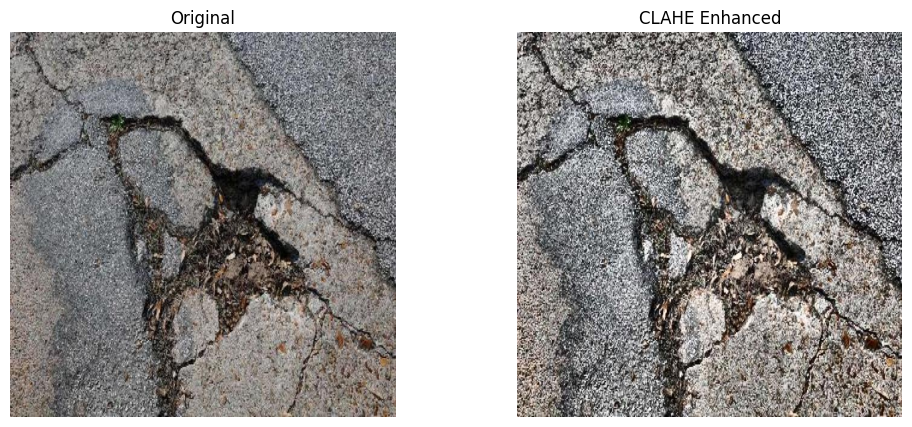

In [ ]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

sample_original = Path(df.iloc[0]["image"])

sample_enhanced = (
    FOLD_ROOT /
    "fold1" /
    ("val/images" if df.iloc[0]["fold"] == 1 else "train/images") /
    sample_original.name
)

original = cv2.cvtColor(
    cv2.imread(str(sample_original)),
    cv2.COLOR_BGR2RGB
)

enhanced = cv2.cvtColor(
    cv2.imread(str(sample_enhanced)),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced)
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.show()

# **Cell 16｜統一訓練參數**

In [ ]:
EPOCHS = 50
IMGSZ = 640
BATCH = 32
SEED = 42
DEVICE = 0

# 老師要求的 augmentation
BRIGHTNESS = 0.20     # ±20%
ROTATION = 10.0       # ±10 degree
SCALE = 0.20          # approximately 0.8–1.2

# **Part A｜先跑 YOLOv8m**

# **Cell 17｜YOLOv8m Fold 1 測試**

In [ ]:
from ultralytics import YOLO

fold = 1

model = YOLO("yolov8m.pt")

results = model.train(
    data=str(FOLD_ROOT / f"fold{fold}/data.yaml"),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    seed=SEED,

    optimizer="SGD",

    # -----------------------
    # Teacher-required aug
    # -----------------------
    degrees=ROTATION,
    scale=SCALE,
    hsv_v=BRIGHTNESS,

    # 關閉額外 augmentation
    fliplr=0.0,
    flipud=0.0,
    shear=0.0,
    mosaic=0.0,
    mixup=0.0,

    project="/content/runs_5fold",
    name=f"YOLOv8m_fold{fold}",

    exist_ok=True,
    verbose=True
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pothole_5fold/fold1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=YOLOv8m_fo

# **Cell 18｜檢查 YOLOv8m Fold 1**

In [ ]:
best_v8 = "/content/runs_5fold/YOLOv8m_fold1/weights/best.pt"

model_v8 = YOLO(best_v8)

metrics = model_v8.val(
    data=str(FOLD_ROOT / "fold1/data.yaml"),
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE
)

print("Precision     :", metrics.box.mp)
print("Recall        :", metrics.box.mr)
print("mAP@0.5      :", metrics.box.map50)
print("mAP@0.5:0.95 :", metrics.box.map)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2428.4±523.2 MB/s, size: 116.5 KB)
val: Scanning /content/pothole_5fold/fold1/val/labels.cache... 1083 images, 633 backgrounds, 7 corrupt: 100% ━━━━━━━━━━━━ 1083/1083 378.5Mit/s 0.0s
val: /content/pothole_5fold/fold1/val/images/447_jpg.rf.8ed765a7e8f523d5910ec03075e8c0b6.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/pothole_5fold/fold1/val/images/598_jpg.rf.1bd3ec6dfae5f340961ff62e53565e10.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/pothole_5fold/fold1/val/images/598_jpg.rf.6a76ef34cd5014899aa3afcd9c6385c7.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/pothole_5fold/fold1/val/images/img-331_jpg.rf.e7ee43779f9381b01ea144abfa40a362.jpg: igno

# **Cell 19｜先修正 mixed polygon / bbox labels**

In [ ]:
from pathlib import Path

def convert_mixed_label_to_bbox(label_path):
    """
    YOLO Detection:
    class xc yc w h

    YOLO Segmentation:
    class x1 y1 x2 y2 ... xn yn
    """

    label_path = Path(label_path)

    if not label_path.exists():
        return 0, 0

    lines = label_path.read_text().strip().splitlines()

    new_lines = []

    converted = 0
    skipped = 0

    for line in lines:

        parts = line.strip().split()

        if len(parts) == 0:
            continue

        # ------------------------
        # Normal bbox
        # ------------------------
        if len(parts) == 5:
            new_lines.append(line)
            continue

        # ------------------------
        # Polygon segmentation
        # ------------------------
        if len(parts) > 5:

            try:
                cls = int(float(parts[0]))

                coords = list(map(float, parts[1:]))

                # segmentation 必須是 x,y pairs
                if len(coords) % 2 != 0:
                    skipped += 1
                    continue

                xs = coords[0::2]
                ys = coords[1::2]

                xmin = max(0.0, min(xs))
                xmax = min(1.0, max(xs))

                ymin = max(0.0, min(ys))
                ymax = min(1.0, max(ys))

                w = xmax - xmin
                h = ymax - ymin

                if w <= 0 or h <= 0:
                    skipped += 1
                    continue

                xc = (xmin + xmax) / 2
                yc = (ymin + ymax) / 2

                new_lines.append(
                    f"{cls} {xc:.6f} {yc:.6f} "
                    f"{w:.6f} {h:.6f}"
                )

                converted += 1

            except Exception:
                skipped += 1

    label_path.write_text("\n".join(new_lines))

    return converted, skipped

# **Cell 20｜把五個 Fold 全部修正**

In [ ]:
converted_total = 0
skipped_total = 0

for fold in range(1, 6):

    for split in ["train", "val"]:

        label_dir = (
            FOLD_ROOT /
            f"fold{fold}" /
            split /
            "labels"
        )

        for label_path in label_dir.glob("*.txt"):

            converted, skipped = convert_mixed_label_to_bbox(
                label_path
            )

            converted_total += converted
            skipped_total += skipped


print("Converted polygon rows :", converted_total)
print("Skipped malformed rows :", skipped_total)

Converted polygon rows : 2135
Skipped malformed rows : 0


# **Cell 21｜刪掉舊 cache**

In [ ]:
for cache_file in FOLD_ROOT.rglob("*.cache"):
    print("Removing:", cache_file)
    cache_file.unlink()

print("Cache removed.")

Removing: /content/pothole_5fold/fold1/val/labels.cache
Removing: /content/pothole_5fold/fold1/train/labels.cache
Cache removed.


# **Cell 22｜重新驗證 YOLOv8m Fold 1**

In [ ]:
from ultralytics import YOLO

best_v8 = (
    "/content/runs_5fold/"
    "YOLOv8m_fold1/weights/best.pt"
)

model_v8 = YOLO(best_v8)

metrics = model_v8.val(
    data=str(FOLD_ROOT / "fold1/data.yaml"),
    imgsz=640,
    batch=32,
    device=0,
    plots=True
)

P = float(metrics.box.mp)
R = float(metrics.box.mr)

F1 = (
    2 * P * R / (P + R)
    if P + R > 0 else 0
)

print()
print("Precision     :", P)
print("Recall        :", R)
print("F1            :", F1)
print("mAP@0.5      :", float(metrics.box.map50))
print("mAP@0.5:0.95 :", float(metrics.box.map))

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2316.6±816.7 MB/s, size: 113.7 KB)
val: Scanning /content/pothole_5fold/fold1/val/labels... 1083 images, 633 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1083/1083 1.8Kit/s 0.6s
val: New cache created: /content/pothole_5fold/fold1/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 5.2it/s 6.6s
                   all       1083       1185      0.787      0.705      0.697      0.359
Speed: 1.0ms preprocess, 2.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val-2

Precision     : 0.7871118020525517
Recall        : 0.7046413502109705
F1            : 0.7435969176585631
mAP@0.5      : 0.6968486592025713
mAP@0.5:0.95 : 0.35896753694544126


# **Cell 23｜取得每張 Validation image 的 score**

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

def get_image_level_scores(
    model_path,
    fold,
    model_name,
    imgsz=640
):

    model = YOLO(model_path)

    val_img_dir = (
        FOLD_ROOT /
        f"fold{fold}" /
        "val/images"
    )

    val_lbl_dir = (
        FOLD_ROOT /
        f"fold{fold}" /
        "val/labels"
    )

    image_files = sorted(
        [
            p for p in val_img_dir.iterdir()
            if p.suffix.lower()
            in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
        ]
    )

    records = []

    for img_path in tqdm(image_files):

        label_path = (
            val_lbl_dir /
            f"{img_path.stem}.txt"
        )

        # -------------------------
        # Ground Truth
        # -------------------------
        if label_path.exists():

            content = label_path.read_text().strip()

            y_true = 1 if content else 0

        else:
            y_true = 0

        # -------------------------
        # Prediction
        # 使用極低 threshold 保留 score
        # -------------------------
        result = model.predict(
            source=str(img_path),
            imgsz=imgsz,
            conf=0.001,
            iou=0.5,
            device=0,
            verbose=False
        )[0]

        if (
            result.boxes is not None
            and len(result.boxes) > 0
        ):

            confidences = (
                result.boxes.conf
                .detach()
                .cpu()
                .numpy()
            )

            y_score = float(
                confidences.max()
            )

        else:
            y_score = 0.0

        records.append({
            "model": model_name,
            "fold": fold,
            "image": str(img_path),
            "y_true": y_true,
            "y_score": y_score
        })

    return pd.DataFrame(records)

# **Cell 24｜先跑 YOLOv8m Fold 1**

In [ ]:
v8_fold1_scores = get_image_level_scores(
    model_path=best_v8,
    fold=1,
    model_name="YOLOv8m"
)

display(v8_fold1_scores.head())

print()
print(
    v8_fold1_scores["y_true"]
    .value_counts()
)

  0%|          | 0/1083 [00:00<?, ?it/s]

,model,fold,image,y_true,y_score
0,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/109_jp...,1,0.801270
1,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/112_jp...,1,0.810357
2,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/114_jp...,1,0.874820
3,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/115_jp...,1,0.842480
4,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/115_jp...,1,0.848005



y_true
0    633
1    450
Name: count, dtype: int64


# **Cell 25｜計算 TPR / FPR / FDR / FOR / MCC**

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef

def calculate_threshold_metrics(
    score_df,
    thresholds=None
):

    if thresholds is None:
        thresholds = np.arange(
            0.10,
            0.91,
            0.10
        )

    rows = []

    y_true = score_df["y_true"].values
    y_score = score_df["y_score"].values

    for threshold in thresholds:

        y_pred = (
            y_score >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        # -----------------------
        # Metrics
        # -----------------------

        TPR = (
            tp / (tp + fn)
            if tp + fn > 0
            else 0
        )

        FPR = (
            fp / (fp + tn)
            if fp + tn > 0
            else 0
        )

        FDR = (
            fp / (tp + fp)
            if tp + fp > 0
            else 0
        )

        FOR = (
            fn / (fn + tn)
            if fn + tn > 0
            else 0
        )

        MCC = matthews_corrcoef(
            y_true,
            y_pred
        )

        rows.append({
            "threshold": threshold,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TPR": TPR,
            "FPR": FPR,
            "FDR": FDR,
            "FOR": FOR,
            "MCC": MCC
        })

    return pd.DataFrame(rows)

# **Cell 26｜顯示 threshold table**

In [ ]:
v8_threshold_metrics = (
    calculate_threshold_metrics(
        v8_fold1_scores
    )
)

display(
    v8_threshold_metrics.round(4)
)

,threshold,TP,TN,FP,FN,TPR,FPR,FDR,FOR,MCC
0,0.1,449,626,7,1,0.9978,0.0111,0.0154,0.0016,0.9849
1,0.2,445,627,6,5,0.9889,0.0095,0.0133,0.0079,0.9791
2,0.3,444,628,5,6,0.9867,0.0079,0.0111,0.0095,0.9791
3,0.4,443,629,4,7,0.9844,0.0063,0.0089,0.0110,0.9791
4,0.5,439,629,4,11,0.9756,0.0063,0.0090,0.0172,0.9715
5,0.6,430,630,3,20,0.9556,0.0047,0.0069,0.0308,0.9565
6,0.7,417,632,1,33,0.9267,0.0016,0.0024,0.0496,0.9365
7,0.8,319,633,0,131,0.7089,0.0000,0.0000,0.1715,0.7664
8,0.9,10,633,0,440,0.0222,0.0000,0.0000,0.4101,0.1145


# **Cell 27｜找 MCC 最佳 threshold**

In [ ]:
best_row = (
    v8_threshold_metrics
    .sort_values(
        "MCC",
        ascending=False
    )
    .iloc[0]
)

print("Best threshold:")
print(best_row)

Best threshold:
threshold      0.100000
TP           449.000000
TN           626.000000
FP             7.000000
FN             1.000000
TPR            0.997778
FPR            0.011058
FDR            0.015351
FOR            0.001595
MCC            0.984885
Name: 0, dtype: float64


# **Cell 28｜畫 TPR / FPR / FDR / FOR / MCC 曲線**

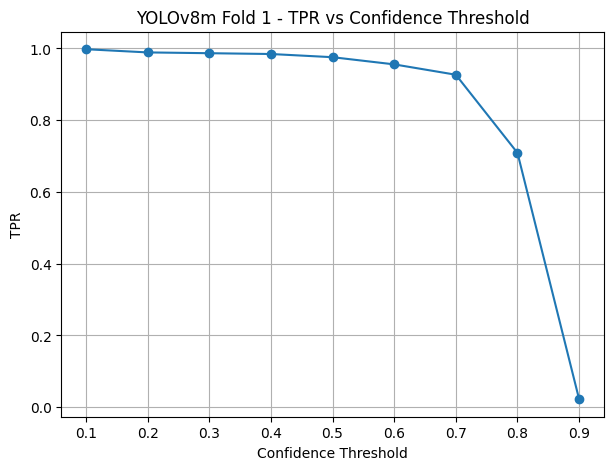

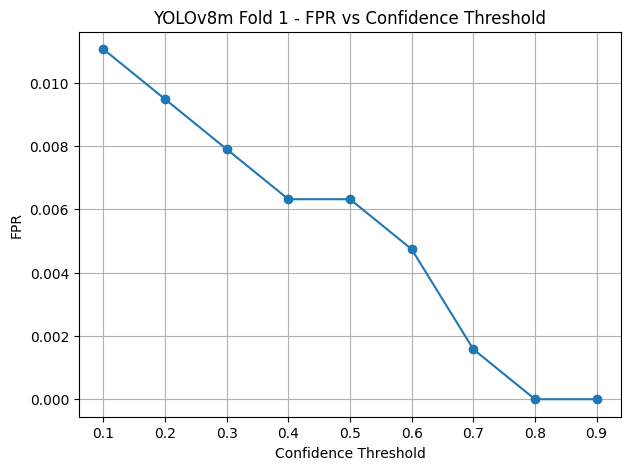

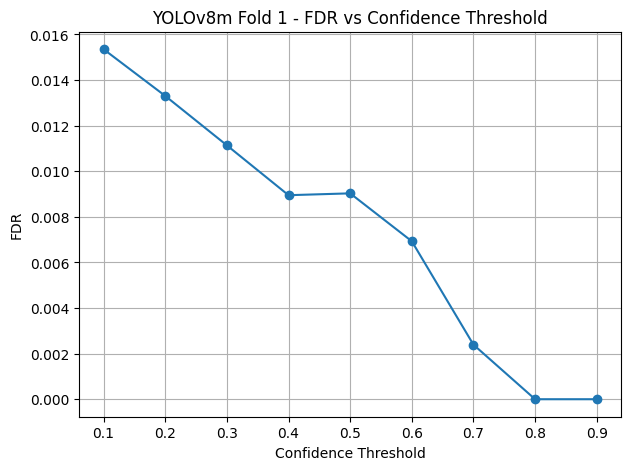

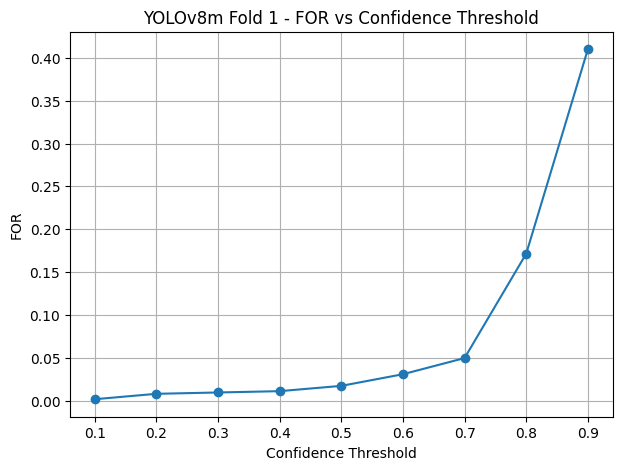

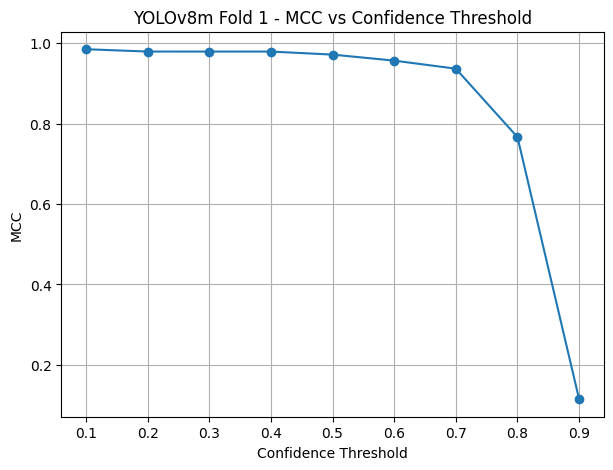

In [ ]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "TPR",
    "FPR",
    "FDR",
    "FOR",
    "MCC"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(7, 5))

    plt.plot(
        v8_threshold_metrics["threshold"],
        v8_threshold_metrics[metric],
        marker="o"
    )

    plt.xlabel("Confidence Threshold")
    plt.ylabel(metric)

    plt.title(
        f"YOLOv8m Fold 1 - "
        f"{metric} vs Confidence Threshold"
    )

    plt.grid(True)

    plt.show()

# **Cell 29｜ROC Curve + AUC**

In [ ]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

y_true = (
    v8_fold1_scores["y_true"]
    .values
)

y_score = (
    v8_fold1_scores["y_score"]
    .values
)

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

auc_value = roc_auc_score(
    y_true,
    y_score
)

print(
    f"YOLOv8m Fold 1 AUC = "
    f"{auc_value:.4f}"
)

YOLOv8m Fold 1 AUC = 0.9993


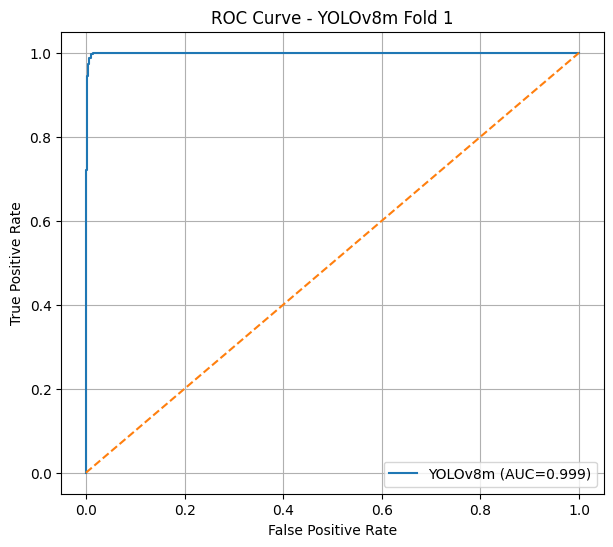

In [ ]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"YOLOv8m (AUC={auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - YOLOv8m Fold 1"
)

plt.legend()

plt.grid(True)

plt.show()

# **Cell 30｜儲存結果**

In [ ]:
v8_fold1_scores.to_csv(
    "/content/YOLOv8m_fold1_image_scores.csv",
    index=False
)

v8_threshold_metrics.to_csv(
    "/content/YOLOv8m_fold1_threshold_metrics.csv",
    index=False
)

print("Saved.")

Saved.


# **Cell 31｜找出 FP / FN**

In [ ]:
BEST_THRESHOLD = float(
    best_row["threshold"]
)

v8_errors = (
    v8_fold1_scores.copy()
)

v8_errors["y_pred"] = (
    v8_errors["y_score"]
    >= BEST_THRESHOLD
).astype(int)

FP_df = v8_errors[
    (v8_errors["y_true"] == 0) &
    (v8_errors["y_pred"] == 1)
].copy()

FN_df = v8_errors[
    (v8_errors["y_true"] == 1) &
    (v8_errors["y_pred"] == 0)
].copy()

print("False Positives:", len(FP_df))
print("False Negatives:", len(FN_df))

False Positives: 7
False Negatives: 1


# **Cell 32｜顯示 False Positives**

In [ ]:
import cv2

def show_error_images(
    error_df,
    title,
    n=6
):

    samples = error_df.head(n)

    if len(samples) == 0:
        print("No images.")
        return

    plt.figure(
        figsize=(15, 8)
    )

    for i, (_, row) in enumerate(
        samples.iterrows()
    ):

        img = cv2.imread(
            row["image"]
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(
            2,
            3,
            i + 1
        )

        plt.imshow(img)

        plt.title(
            f"score={row['y_score']:.3f}"
        )

        plt.axis("off")

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

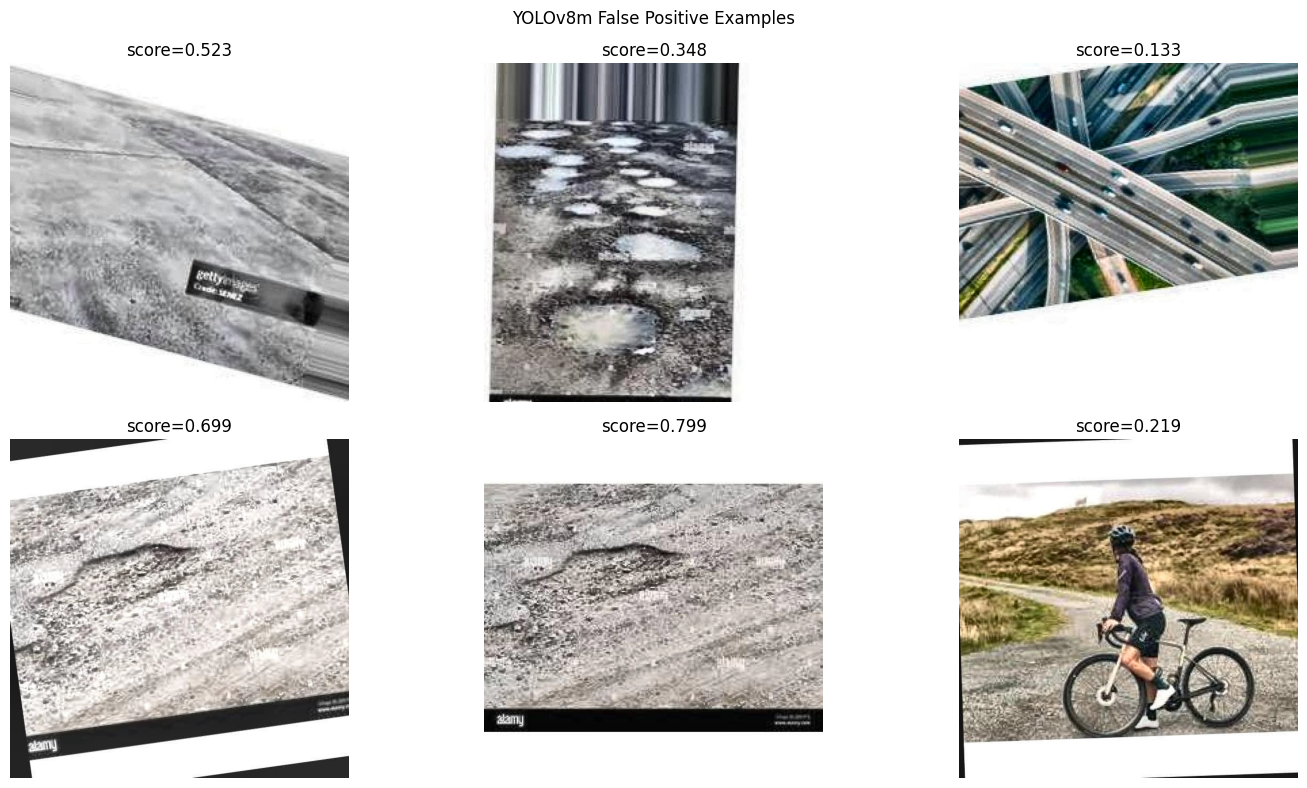

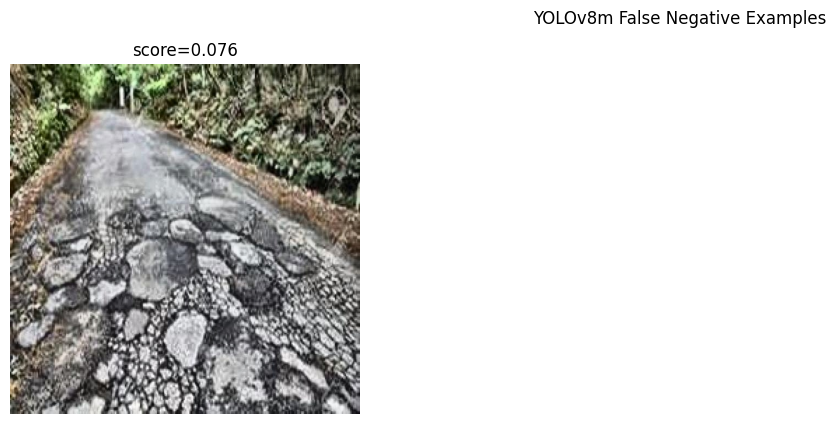

In [ ]:
show_error_images(
    FP_df,
    "YOLOv8m False Positive Examples"
)

show_error_images(
    FN_df,
    "YOLOv8m False Negative Examples"
)

# FP 常見原因    
shadow/
road patch/
dark asphalt/
crack/
manhole/
water/
rough surface

# FN 常見原因
small pothole/
low contrast/
far distance/
partially visible pothole/
strong illumination/
blurred pothole/

# **Cell 33｜Batch=1 Benchmark**

In [ ]:
import time
import torch
import numpy as np

def benchmark_model(
    model_path,
    fold=1,
    warmup=20,
    max_images=300
):

    model = YOLO(model_path)

    val_img_dir = (
        FOLD_ROOT /
        f"fold{fold}/val/images"
    )

    image_files = sorted(
        list(val_img_dir.glob("*"))
    )

    image_files = image_files[
        :min(max_images, len(image_files))
    ]

    # -----------------------
    # Warm-up
    # -----------------------
    for img_path in image_files[:warmup]:

        model.predict(
            source=str(img_path),
            imgsz=640,
            device=0,
            batch=1,
            verbose=False
        )

    torch.cuda.synchronize()

    inference_times = []
    total_times = []

    for img_path in image_files:

        torch.cuda.synchronize()

        start = time.perf_counter()

        result = model.predict(
            source=str(img_path),
            imgsz=640,
            device=0,
            batch=1,
            verbose=False
        )[0]

        torch.cuda.synchronize()

        end = time.perf_counter()

        total_ms = (
            end - start
        ) * 1000

        inference_ms = (
            result.speed.get(
                "inference",
                np.nan
            )
        )

        total_times.append(
            total_ms
        )

        inference_times.append(
            inference_ms
        )

    avg_inference = np.nanmean(
        inference_times
    )

    avg_total = np.mean(
        total_times
    )

    inference_fps = (
        1000 / avg_inference
    )

    end_to_end_fps = (
        1000 / avg_total
    )

    return {
        "inference_ms": avg_inference,
        "end_to_end_ms": avg_total,
        "inference_fps": inference_fps,
        "end_to_end_fps": end_to_end_fps
    }

# **Cell 34｜YOLOv8m FPS**

In [ ]:
v8_speed = benchmark_model(
    best_v8,
    fold=1
)

print(v8_speed)

{'inference_ms': np.float64(8.706627739990532), 'end_to_end_ms': np.float64(13.645981086683605), 'inference_fps': np.float64(114.85503111691409), 'end_to_end_fps': np.float64(73.28164927444077)}


# **Cell 35｜YOLOv8m Fold 2–5**

In [ ]:
from ultralytics import YOLO

for fold in range(2, 6):

    print()
    print("=" * 60)
    print(
        f"Training YOLOv8m Fold {fold}"
    )
    print("=" * 60)

    model = YOLO(
        "yolov8m.pt"
    )

    model.train(

        data=str(
            FOLD_ROOT /
            f"fold{fold}/data.yaml"
        ),

        epochs=50,
        imgsz=640,
        batch=32,

        optimizer="SGD",

        device=0,
        seed=42,

        # teacher-required augmentation
        degrees=10.0,
        scale=0.20,
        hsv_v=0.20,

        # 關掉額外 augmentation
        hsv_h=0.0,
        hsv_s=0.0,

        fliplr=0.0,
        flipud=0.0,

        shear=0.0,
        mosaic=0.0,
        mixup=0.0,

        project="/content/runs_5fold",

        name=f"YOLOv8m_fold{fold}",

        exist_ok=True
    )


Training YOLOv8m Fold 2
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pothole_5fold/fold2/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.0, multi_sca

# **Cell 36｜重新整理 YOLOv8m 五折標準 Detection Results**

In [ ]:
v8_detection_results = []

for fold in range(1, 6):

    best_path = (
        f"/content/runs_5fold/"
        f"YOLOv8m_fold{fold}/"
        f"weights/best.pt"
    )

    model = YOLO(
        best_path
    )

    metrics = model.val(

        data=str(
            FOLD_ROOT /
            f"fold{fold}/data.yaml"
        ),

        imgsz=640,
        batch=32,
        device=0,
        verbose=False
    )

    P = float(
        metrics.box.mp
    )

    R = float(
        metrics.box.mr
    )

    F1 = (
        2 * P * R /
        (P + R)
        if P + R > 0
        else 0
    )

    v8_detection_results.append({
        "model": "YOLOv8m",
        "fold": fold,
        "precision": P,
        "recall": R,
        "f1": F1,
        "map50": float(
            metrics.box.map50
        ),
        "map50_95": float(
            metrics.box.map
        )
    })


v8_detection_df = pd.DataFrame(
    v8_detection_results
)

display(
    v8_detection_df
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2110.2±403.8 MB/s, size: 112.5 KB)
val: Scanning /content/pothole_5fold/fold1/val/labels.cache... 1083 images, 633 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1083/1083 324.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 5.1it/s 6.7s
                   all       1083       1185      0.787      0.705      0.697      0.359
Speed: 1.0ms preprocess, 2.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val-3
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2378.9±659.5 MB/s

,model,fold,precision,recall,f1,map50,map50_95
0,YOLOv8m,1,0.787112,0.704641,0.743597,0.696849,0.358968
1,YOLOv8m,2,0.780732,0.760797,0.770636,0.768229,0.410232
2,YOLOv8m,3,0.818572,0.729185,0.771297,0.761113,0.413753
3,YOLOv8m,4,0.822778,0.703912,0.758718,0.716481,0.388663
4,YOLOv8m,5,0.806281,0.741468,0.772517,0.754751,0.394682


# **Cell 37｜Mean ± SD**

In [ ]:
v8_summary = (
    v8_detection_df[
        [
            "precision",
            "recall",
            "f1",
            "map50",
            "map50_95"
        ]
    ]
    .agg(["mean", "std"])
    .T
)

display(v8_summary)

,mean,std
precision,0.803095,0.018659
recall,0.728001,0.024415
f1,0.763353,0.012368
map50,0.739484,0.031121
map50_95,0.393260,0.021836


# **Cell 38｜取得 YOLOv8m 五 Fold Out-of-Fold Score**

In [ ]:
all_v8_scores = []

for fold in range(1, 6):

    print(
        f"Evaluating YOLOv8m Fold {fold}"
    )

    best_path = (
        f"/content/runs_5fold/"
        f"YOLOv8m_fold{fold}/"
        f"weights/best.pt"
    )

    fold_scores = get_image_level_scores(

        model_path=best_path,

        fold=fold,

        model_name="YOLOv8m"
    )

    all_v8_scores.append(
        fold_scores
    )


v8_oof_scores = pd.concat(
    all_v8_scores,
    ignore_index=True
)

print(
    "OOF images:",
    len(v8_oof_scores)
)

display(
    v8_oof_scores.head()
)

Evaluating YOLOv8m Fold 1


  0%|          | 0/1083 [00:00<?, ?it/s]

Evaluating YOLOv8m Fold 2


  0%|          | 0/1083 [00:00<?, ?it/s]

Evaluating YOLOv8m Fold 3


...

  0%|          | 0/1082 [00:00<?, ?it/s]

Evaluating YOLOv8m Fold 5


  0%|          | 0/1082 [00:00<?, ?it/s]

OOF images: 5413


,model,fold,image,y_true,y_score
0,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/109_jp...,1,0.801270
1,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/112_jp...,1,0.810357
2,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/114_jp...,1,0.874820
3,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/115_jp...,1,0.842480
4,YOLOv8m,1,/content/pothole_5fold/fold1/val/images/115_jp...,1,0.848005


# **Cell 39｜YOLOv8m 最終 Extended Metrics**

In [ ]:
v8_oof_metrics = (
    calculate_threshold_metrics(
        v8_oof_scores
    )
)

display(
    v8_oof_metrics.round(4)
)

,threshold,TP,TN,FP,FN,TPR,FPR,FDR,FOR,MCC
0,0.1,2240,3129,37,7,0.9969,0.0117,0.0162,0.0022,0.9834
1,0.2,2227,3141,25,20,0.9911,0.0079,0.0111,0.0063,0.9829
2,0.3,2213,3149,17,34,0.9849,0.0054,0.0076,0.0107,0.9806
3,0.4,2203,3155,11,44,0.9804,0.0035,0.0050,0.0138,0.9791
4,0.5,2180,3160,6,67,0.9702,0.0019,0.0027,0.0208,0.9724
5,0.6,2142,3161,5,105,0.9533,0.0016,0.0023,0.0321,0.9586
6,0.7,2057,3163,3,190,0.9154,0.0009,0.0015,0.0567,0.9281
7,0.8,1591,3164,2,656,0.7081,0.0006,0.0013,0.1717,0.7649
8,0.9,45,3166,0,2202,0.0200,0.0000,0.0000,0.4102,0.1087


# **Cell 40｜YOLOv8m 最終 ROC/AUC**

YOLOv8m OOF AUC = 0.9991


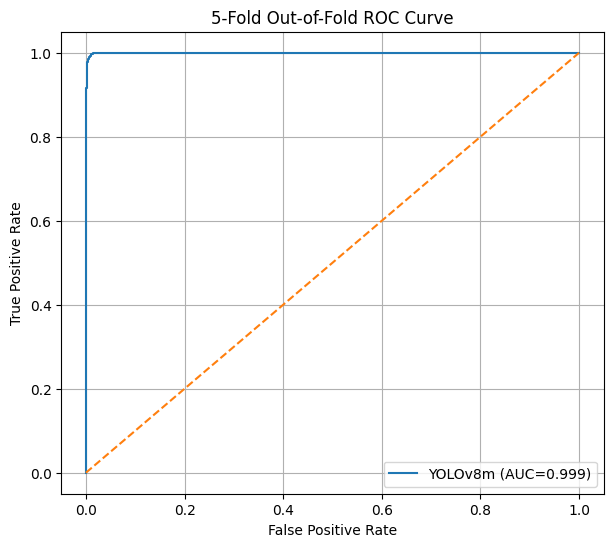

In [ ]:
y_true = (
    v8_oof_scores["y_true"]
    .values
)

y_score = (
    v8_oof_scores["y_score"]
    .values
)

v8_fpr, v8_tpr, _ = roc_curve(
    y_true,
    y_score
)

v8_auc = roc_auc_score(
    y_true,
    y_score
)

print(
    f"YOLOv8m OOF AUC = "
    f"{v8_auc:.4f}"
)

plt.figure(figsize=(7, 6))

plt.plot(
    v8_fpr,
    v8_tpr,
    label=f"YOLOv8m (AUC={v8_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "5-Fold Out-of-Fold ROC Curve"
)

plt.legend()

plt.grid(True)

plt.show()

# **Cell 41｜先測 YOLO26m Fold 1**

In [ ]:
from ultralytics import YOLO

fold = 1

model26 = YOLO("yolo26m.pt")

model26.train(
    data=str(FOLD_ROOT / f"fold{fold}/data.yaml"),

    epochs=50,
    imgsz=640,
    batch=32,

    optimizer="SGD",
    device=0,
    seed=42,

    # Teacher-required augmentation
    degrees=10.0,    # rotation ±10°
    scale=0.20,      # scaling
    hsv_v=0.20,      # brightness variance

    # 關閉其他 augmentation
    hsv_h=0.0,
    hsv_s=0.0,
    fliplr=0.0,
    flipud=0.0,
    shear=0.0,
    mosaic=0.0,
    mixup=0.0,

    project="/content/runs_5fold",
    name="YOLO26m_fold1",

    exist_ok=True
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pothole_5fold/fold1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=YOLO26m_fold

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d5d41f56a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

# **Cell 42｜YOLO26m Fold 1 Validation**

In [ ]:
from ultralytics import YOLO

best_y26 = (
    "/content/runs_5fold/"
    "YOLO26m_fold1/weights/best.pt"
)

model26_best = YOLO(best_y26)

metrics26 = model26_best.val(
    data=str(FOLD_ROOT / "fold1/data.yaml"),
    imgsz=640,
    batch=32,
    device=0,
    plots=True
)

P = float(metrics26.box.mp)
R = float(metrics26.box.mr)

F1 = (
    2 * P * R / (P + R)
    if P + R > 0 else 0
)

print("Precision     :", P)
print("Recall        :", R)
print("F1            :", F1)
print("mAP@0.5      :", float(metrics26.box.map50))
print("mAP@0.5:0.95 :", float(metrics26.box.map))

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 68.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2287.6±382.6 MB/s, size: 112.5 KB)
val: Scanning /content/pothole_5fold/fold1/val/labels.cache... 1083 images, 633 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1083/1083 412.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 5.2it/s 6.5s
                   all       1083       1185      0.802       0.69       0.74      0.373
Speed: 0.8ms preprocess, 2.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val-8
Precision     : 0.8019694147044613
Recall        : 0.6903329066362536
F1            : 0.7419754954062082
mAP@0.5      : 0.7400227475505052
mAP@0.5:0.95 : 0.37303777944466665


# **Cell 43｜YOLO26m Fold 2–5**

In [ ]:
from ultralytics import YOLO

for fold in range(2, 6):

    print()
    print("=" * 65)
    print(f"Training YOLO26m Fold {fold}")
    print("=" * 65)

    model = YOLO("yolo26m.pt")

    model.train(
        data=str(
            FOLD_ROOT /
            f"fold{fold}/data.yaml"
        ),

        epochs=50,
        imgsz=640,
        batch=32,

        optimizer="SGD",
        device=0,
        seed=42,

        degrees=10.0,
        scale=0.20,
        hsv_v=0.20,

        hsv_h=0.0,
        hsv_s=0.0,

        fliplr=0.0,
        flipud=0.0,

        shear=0.0,
        mosaic=0.0,
        mixup=0.0,

        project="/content/runs_5fold",
        name=f"YOLO26m_fold{fold}",

        exist_ok=True
    )


Training YOLO26m Fold 2
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pothole_5fold/fold2/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=0.0, multi_sca

# **Cell 44｜整理 YOLO26m 五折 Detection Results**

In [ ]:
import pandas as pd
from ultralytics import YOLO

y26_detection_results = []

for fold in range(1, 6):

    best_path = (
        f"/content/runs_5fold/"
        f"YOLO26m_fold{fold}/"
        f"weights/best.pt"
    )

    model = YOLO(best_path)

    metrics = model.val(
        data=str(
            FOLD_ROOT /
            f"fold{fold}/data.yaml"
        ),
        imgsz=640,
        batch=32,
        device=0,
        verbose=False
    )

    P = float(metrics.box.mp)
    R = float(metrics.box.mr)

    F1 = (
        2 * P * R / (P + R)
        if P + R > 0
        else 0
    )

    y26_detection_results.append({
        "model": "YOLO26m",
        "fold": fold,
        "precision": P,
        "recall": R,
        "f1": F1,
        "map50": float(metrics.box.map50),
        "map50_95": float(metrics.box.map)
    })


y26_detection_df = pd.DataFrame(
    y26_detection_results
)

display(y26_detection_df)

# **Cell 45｜YOLO26m Mean ± SD**

In [ ]:
y26_summary = (
    y26_detection_df[
        [
            "precision",
            "recall",
            "f1",
            "map50",
            "map50_95"
        ]
    ]
    .agg(["mean", "std"])
    .T
)

display(y26_summary)

# **Cell 46｜YOLO26m 五折 Image-Level Scores**

In [ ]:
all_y26_scores = []

for fold in range(1, 6):

    print(f"Evaluating YOLO26m Fold {fold}")

    best_path = (
        f"/content/runs_5fold/"
        f"YOLO26m_fold{fold}/"
        f"weights/best.pt"
    )

    fold_scores = get_image_level_scores(
        model_path=best_path,
        fold=fold,
        model_name="YOLO26m"
    )

    all_y26_scores.append(
        fold_scores
    )


y26_oof_scores = pd.concat(
    all_y26_scores,
    ignore_index=True
)

print(
    "YOLO26m OOF images:",
    len(y26_oof_scores)
)

display(
    y26_oof_scores.head()
)

# **Cell 47｜YOLO26m TPR / FPR / FDR / FOR / MCC**

In [ ]:
y26_oof_metrics = (
    calculate_threshold_metrics(
        y26_oof_scores
    )
)

display(
    y26_oof_metrics.round(4)
)

# **Cell 48｜找 YOLO26m 最佳 MCC Threshold**

In [ ]:
best_y26_threshold = (
    y26_oof_metrics
    .sort_values(
        "MCC",
        ascending=False
    )
    .iloc[0]
)

print(best_y26_threshold)

# **Cell 49｜YOLO26m ROC + AUC**

In [ ]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

y_true = y26_oof_scores["y_true"].values
y_score = y26_oof_scores["y_score"].values

y26_fpr, y26_tpr, _ = roc_curve(
    y_true,
    y_score
)

y26_auc = roc_auc_score(
    y_true,
    y_score
)

print(
    f"YOLO26m OOF AUC = "
    f"{y26_auc:.4f}"
)

plt.figure(figsize=(7, 6))

plt.plot(
    y26_fpr,
    y26_tpr,
    label=f"YOLO26m (AUC={y26_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "YOLO26m 5-Fold Out-of-Fold ROC"
)

plt.legend()
plt.grid(True)

plt.show()

# **Cell 50｜YOLO26m FPS / Latency**

In [ ]:
y26_speed = benchmark_model(
    "/content/runs_5fold/"
    "YOLO26m_fold1/weights/best.pt",
    fold=1
)

print(y26_speed)